In [1]:
# aperiodic: uses_preview_data

# Alpha Discovery with Smoothed Microstructure Signals
#
This notebook extends the alpha-discovery workflow by searching two dimensions:
rank-window normalization and moving-average smoothing.

Each feature is converted into a rolling percentile-rank signal, then optionally
smoothed with a short moving average to reduce noise before evaluating the next-bar
return relationship and a simple position backtest.

In [2]:

from __future__ import annotations

import datetime
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aperiodic import get_derivative_metrics, get_metrics, get_ohlcv
from utils._aperiodic_demo import run_position_backtest

SYMBOL = "perpetual-BTC-USDT:USDT"
EXCHANGE = "binance-futures"
INTERVAL = "5m"
TIMESTAMP = "exchange"  # local timestamp or "true"

START_DATE = datetime.date(2025, 5, 1)
END_DATE = datetime.date(2025, 5, 31)

METRICS = [
    ("basis", "derivative"),
    ("funding", "derivative"),
    ("open_interest", "derivative"),
    ("flow", "regular"),
    ("impact", "regular"),
    # ("l1_imbalance", "regular"),
    # ("l1_liquidity", "regular"),
    # ("l2_imbalance", "regular"),
    # ("l2_liquidity", "regular"),
    ("returns", "regular"),
    ("slippage", "regular"),
    ("trade_size", "regular"),
    ("updownticks", "regular"),
    ("run_structure", "regular"),
    ("vtwap", "regular"),
    ("range", "regular"),
]

RANK_WINDOWS = [100, 300, 600, 1200]
SMOOTH_WINDOWS = [1, 5, 10, 15, 50]
COST_BPS = 0.0

API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    raise RuntimeError("Set APERIODIC_API_KEY in the environment or in .env.")


def get_numeric_metric_frame(metric: str, kind: str) -> pd.DataFrame | None:
    fetcher = get_derivative_metrics if kind == "derivative" else get_metrics
    raw_df = fetcher(
        api_key=API_KEY,
        metric=metric,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    df = raw_df.to_pandas() if hasattr(raw_df, "to_pandas") else pd.DataFrame(raw_df)

    if df.empty or "time" not in df.columns:
        print(f"Skipping {metric}: no rows returned.")
        return None

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if "time" in numeric_cols:
        numeric_cols.remove("time")

    if not numeric_cols:
        print(f"Skipping {metric}: no numeric columns returned.")
        return None

    return df.sort_values("time").drop_duplicates(subset=["time"], keep="last")[
        ["time", *numeric_cols]
    ]


def build_panel() -> tuple[pd.DataFrame, list[str]]:
    raw_ohlcv = get_ohlcv(
        api_key=API_KEY,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    panel = (
        raw_ohlcv.to_pandas() if hasattr(raw_ohlcv, "to_pandas") else pd.DataFrame(raw_ohlcv)
    )
    panel = panel.sort_values("time")[["time", "close"]]

    for metric, kind in METRICS:
        frame = get_numeric_metric_frame(metric, kind)
        if frame is None:
            continue

        numeric_feature_cols = [col for col in frame.columns if col != "time"]
        if frame[numeric_feature_cols].notna().sum().sum() == 0:
            print(f"Skipping {metric}: all feature values are null.")
            continue

        panel = panel.merge(frame, on="time", how="left")

    panel = panel.sort_values("time")
    feature_cols = [
        col
        for col in panel.columns
        if col not in {"time", "close"}
        and pd.api.types.is_numeric_dtype(panel[col])
    ]

    panel[feature_cols] = panel[feature_cols].ffill()
    panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
    panel = panel.dropna(subset=["fwd_ret"])

    print(f"Panel built: {len(panel)} rows. Found {len(feature_cols)} features.")
    return panel, feature_cols


def smooth_feature(panel_df: pd.DataFrame, feature: str, window: int) -> np.ndarray:
    values = panel_df[feature].to_numpy().astype(np.float64)
    if window <= 1:
        return values.copy()

    return pd.Series(values).rolling(window).mean().to_numpy().astype(np.float64)


def make_rank_signal(values: np.ndarray, window: int) -> np.ndarray:
    rank = pd.Series(values).rolling(window).rank(method="average")
    signal = ((rank - 1.0) / (window - 1)) * 2.0 - 1.0
    return signal.to_numpy().astype(np.float64)


panel, feature_cols = build_panel()

print(f"Rows: {len(panel):,}")
print(f"Features: {feature_cols}")
print(panel.head())

Panel built: 8927 rows. Found 129 features.
Rows: 8,927
Features: ['basis', 'basis_bps', 'mark_price_spread', 'mark_price_spread_bps', 'basis_mean', 'basis_bps_std', 'mark_price_spread_mean', 'mark_price_spread_bps_std', 'funding_rate', 'funding_rate_update_frequency', 'funding_rate_avg_update_interval', 'open_interest', 'open_interest_pct_change', 'open_interest_volatility', 'oi_price_change_ratio', 'taker_buy_volume', 'taker_sell_volume', 'taker_buy_count', 'taker_sell_count', 'volume_delta', 'volume_delta_notional', 'flow_entropy', 'flow_toxicity_score', 'taker_buy_sell_ratio', 'taker_buy_sell_count_ratio', 'taker_buy_sell_percentage', 'taker_buy_sell_count_percentage', 'taker_buy_small_order_volume', 'taker_buy_small_order_count', 'taker_buy_medium_order_volume', 'taker_buy_medium_order_count', 'taker_buy_large_order_volume', 'taker_buy_large_order_count', 'taker_sell_small_order_volume', 'taker_sell_small_order_count', 'taker_sell_medium_order_volume', 'taker_sell_medium_order_cou

/tmp/ipykernel_2405/1934409925.py:125: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel["fwd_ret"] = panel["close"].pct_change().shift(-1)


In [3]:
# Evaluate each feature across rank windows and smoothing windows.
forward_returns = panel["fwd_ret"].to_numpy().astype(np.float64)
results = []

for feature in feature_cols:
    for smooth_window in SMOOTH_WINDOWS:
        smoothed_feature = smooth_feature(panel, feature, smooth_window)

        for rank_window in RANK_WINDOWS:
            signal = make_rank_signal(smoothed_feature, rank_window)
            mask = np.isfinite(signal) & np.isfinite(forward_returns)

            print(
                "Testing "
                f"{feature} | rank_window {rank_window} | smooth_window {smooth_window}: "
                f"{mask.sum()} valid observations"
            )

            signal_valid = signal[mask]
            returns_valid = forward_returns[mask]
            if (
                signal_valid.size < 2
                or np.std(signal_valid) == 0.0
                or np.std(returns_valid) == 0.0
            ):
                continue

            fit_corr = float(np.corrcoef(signal_valid, returns_valid)[0, 1])
            if not np.isfinite(fit_corr):
                continue

            direction = 1 if fit_corr >= 0 else -1
            _, bt_summary = run_position_backtest(
                timestamps=panel.loc[mask, "time"],
                position=np.nan_to_num(
                    np.clip(signal_valid * direction, -1.0, 1.0), nan=0.0
                ),
                forward_return=returns_valid,
                cost_bps_one_way=COST_BPS,
            )

            results.append(
                {
                    "feature": feature,
                    "rank_window": rank_window,
                    "smooth_window": smooth_window,
                    "direction": direction,
                    "fit_corr": fit_corr,
                    "sharpe": bt_summary["annualized_sharpe"],
                    "total_return": bt_summary["net_return_pct"],
                    "max_drawdown": bt_summary["max_drawdown_pct"],
                }
            )

if not results:
    raise RuntimeError(
        "No valid feature/window combinations were produced. "
        "Check the fetched metric coverage for the selected date range."
    )

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df.head(50).to_markdown(index=False))

Testing basis | rank_window 100 | smooth_window 1: 8828 valid observations
Testing basis | rank_window 300 | smooth_window 1: 8628 valid observations
Testing basis | rank_window 600 | smooth_window 1: 8328 valid observations
Testing basis | rank_window 1200 | smooth_window 1: 7728 valid observations
Testing basis | rank_window 100 | smooth_window 5: 8824 valid observations
Testing basis | rank_window 300 | smooth_window 5: 8624 valid observations
Testing basis | rank_window 600 | smooth_window 5: 8324 valid observations
Testing basis | rank_window 1200 | smooth_window 5: 7724 valid observations
Testing basis | rank_window 100 | smooth_window 10: 8819 valid observations
Testing basis | rank_window 300 | smooth_window 10: 8619 valid observations
Testing basis | rank_window 600 | smooth_window 10: 8319 valid observations
Testing basis | rank_window 1200 | smooth_window 10: 7719 valid observations
Testing basis | rank_window 100 | smooth_window 15: 8814 valid observations
Testing basis | r

Testing basis_bps | rank_window 100 | smooth_window 15: 8814 valid observations
Testing basis_bps | rank_window 300 | smooth_window 15: 8614 valid observations
Testing basis_bps | rank_window 600 | smooth_window 15: 8314 valid observations
Testing basis_bps | rank_window 1200 | smooth_window 15: 7714 valid observations


Testing basis_bps | rank_window 100 | smooth_window 50: 8779 valid observations
Testing basis_bps | rank_window 300 | smooth_window 50: 8579 valid observations
Testing basis_bps | rank_window 600 | smooth_window 50: 8279 valid observations
Testing basis_bps | rank_window 1200 | smooth_window 50: 7679 valid observations
Testing mark_price_spread | rank_window 100 | smooth_window 1: 8828 valid observations
Testing mark_price_spread | rank_window 300 | smooth_window 1: 8628 valid observations
Testing mark_price_spread | rank_window 600 | smooth_window 1: 8328 valid observations
Testing mark_price_spread | rank_window 1200 | smooth_window 1: 7728 valid observations
Testing mark_price_spread | rank_window 100 | smooth_window 5: 8824 valid observations
Testing mark_price_spread | rank_window 300 | smooth_window 5: 8624 valid observations
Testing mark_price_spread | rank_window 600 | smooth_window 5: 8324 valid observations
Testing mark_price_spread | rank_window 1200 | smooth_window 5: 7724 

Testing mark_price_spread_bps | rank_window 300 | smooth_window 10: 8619 valid observations
Testing mark_price_spread_bps | rank_window 600 | smooth_window 10: 8319 valid observations
Testing mark_price_spread_bps | rank_window 1200 | smooth_window 10: 7719 valid observations
Testing mark_price_spread_bps | rank_window 100 | smooth_window 15: 8814 valid observations


Testing mark_price_spread_bps | rank_window 300 | smooth_window 15: 8614 valid observations
Testing mark_price_spread_bps | rank_window 600 | smooth_window 15: 8314 valid observations
Testing mark_price_spread_bps | rank_window 1200 | smooth_window 15: 7714 valid observations
Testing mark_price_spread_bps | rank_window 100 | smooth_window 50: 8779 valid observations
Testing mark_price_spread_bps | rank_window 300 | smooth_window 50: 8579 valid observations
Testing mark_price_spread_bps | rank_window 600 | smooth_window 50: 8279 valid observations
Testing mark_price_spread_bps | rank_window 1200 | smooth_window 50: 7679 valid observations
Testing basis_mean | rank_window 100 | smooth_window 1: 8828 valid observations
Testing basis_mean | rank_window 300 | smooth_window 1: 8628 valid observations
Testing basis_mean | rank_window 600 | smooth_window 1: 8328 valid observations
Testing basis_mean | rank_window 1200 | smooth_window 1: 7728 valid observations
Testing basis_mean | rank_window 

...

Testing price_variance | rank_window 100 | smooth_window 10: 8819 valid observations
Testing price_variance | rank_window 300 | smooth_window 10: 8619 valid observations
Testing price_variance | rank_window 600 | smooth_window 10: 8319 valid observations
Testing price_variance | rank_window 1200 | smooth_window 10: 7719 valid observations
Testing price_variance | rank_window 100 | smooth_window 15: 8814 valid observations
Testing price_variance | rank_window 300 | smooth_window 15: 8614 valid observations
Testing price_variance | rank_window 600 | smooth_window 15: 8314 valid observations
Testing price_variance | rank_window 1200 | smooth_window 15: 7714 valid observations
Testing price_variance | rank_window 100 | smooth_window 50: 8779 valid observations
Testing price_variance | rank_window 300 | smooth_window 50: 8579 valid observations
Testing price_variance | rank_window 600 | smooth_window 50: 8279 valid observations
Testing price_variance | rank_window 1200 | smooth_window 50: 7

Testing price_kurtosis | rank_window 300 | smooth_window 1: 8628 valid observations
Testing price_kurtosis | rank_window 600 | smooth_window 1: 8328 valid observations
Testing price_kurtosis | rank_window 1200 | smooth_window 1: 7728 valid observations


Testing price_kurtosis | rank_window 100 | smooth_window 5: 8824 valid observations
Testing price_kurtosis | rank_window 300 | smooth_window 5: 8624 valid observations
Testing price_kurtosis | rank_window 600 | smooth_window 5: 8324 valid observations
Testing price_kurtosis | rank_window 1200 | smooth_window 5: 7724 valid observations
Testing price_kurtosis | rank_window 100 | smooth_window 10: 8819 valid observations
Testing price_kurtosis | rank_window 300 | smooth_window 10: 8619 valid observations
Testing price_kurtosis | rank_window 600 | smooth_window 10: 8319 valid observations
Testing price_kurtosis | rank_window 1200 | smooth_window 10: 7719 valid observations
Testing price_kurtosis | rank_window 100 | smooth_window 15: 8814 valid observations
Testing price_kurtosis | rank_window 300 | smooth_window 15: 8614 valid observations
Testing price_kurtosis | rank_window 600 | smooth_window 15: 8314 valid observations
Testing price_kurtosis | rank_window 1200 | smooth_window 15: 7714 

Testing price_range_ratio | rank_window 600 | smooth_window 50: 8279 valid observations
Testing price_range_ratio | rank_window 1200 | smooth_window 50: 7679 valid observations
Testing price_cv | rank_window 100 | smooth_window 1: 8828 valid observations
Testing price_cv | rank_window 300 | smooth_window 1: 8628 valid observations


Testing price_cv | rank_window 600 | smooth_window 1: 8328 valid observations
Testing price_cv | rank_window 1200 | smooth_window 1: 7728 valid observations
Testing price_cv | rank_window 100 | smooth_window 5: 8824 valid observations
Testing price_cv | rank_window 300 | smooth_window 5: 8624 valid observations
Testing price_cv | rank_window 600 | smooth_window 5: 8324 valid observations
Testing price_cv | rank_window 1200 | smooth_window 5: 7724 valid observations
Testing price_cv | rank_window 100 | smooth_window 10: 8819 valid observations
Testing price_cv | rank_window 300 | smooth_window 10: 8619 valid observations
Testing price_cv | rank_window 600 | smooth_window 10: 8319 valid observations
Testing price_cv | rank_window 1200 | smooth_window 10: 7719 valid observations
Testing price_cv | rank_window 100 | smooth_window 15: 8814 valid observations
Testing price_cv | rank_window 300 | smooth_window 15: 8614 valid observations
Testing price_cv | rank_window 600 | smooth_window 15: 

## Takeaways

Moving-average smoothing adds a second degree of freedom to the alpha search.
Short smoothing windows can suppress microstructure noise, while longer windows
can expose more persistent order-flow or positioning regimes.

Best Strategy found:
{'feature': 'flow_toxicity_score', 'rank_window': 100, 'smooth_window': 50, 'direction': -1, 'fit_corr': -0.031052508983397724, 'sharpe': 10.14962976628629, 'total_return': 23.73998457254398, 'max_drawdown': -2.9586433573524618}


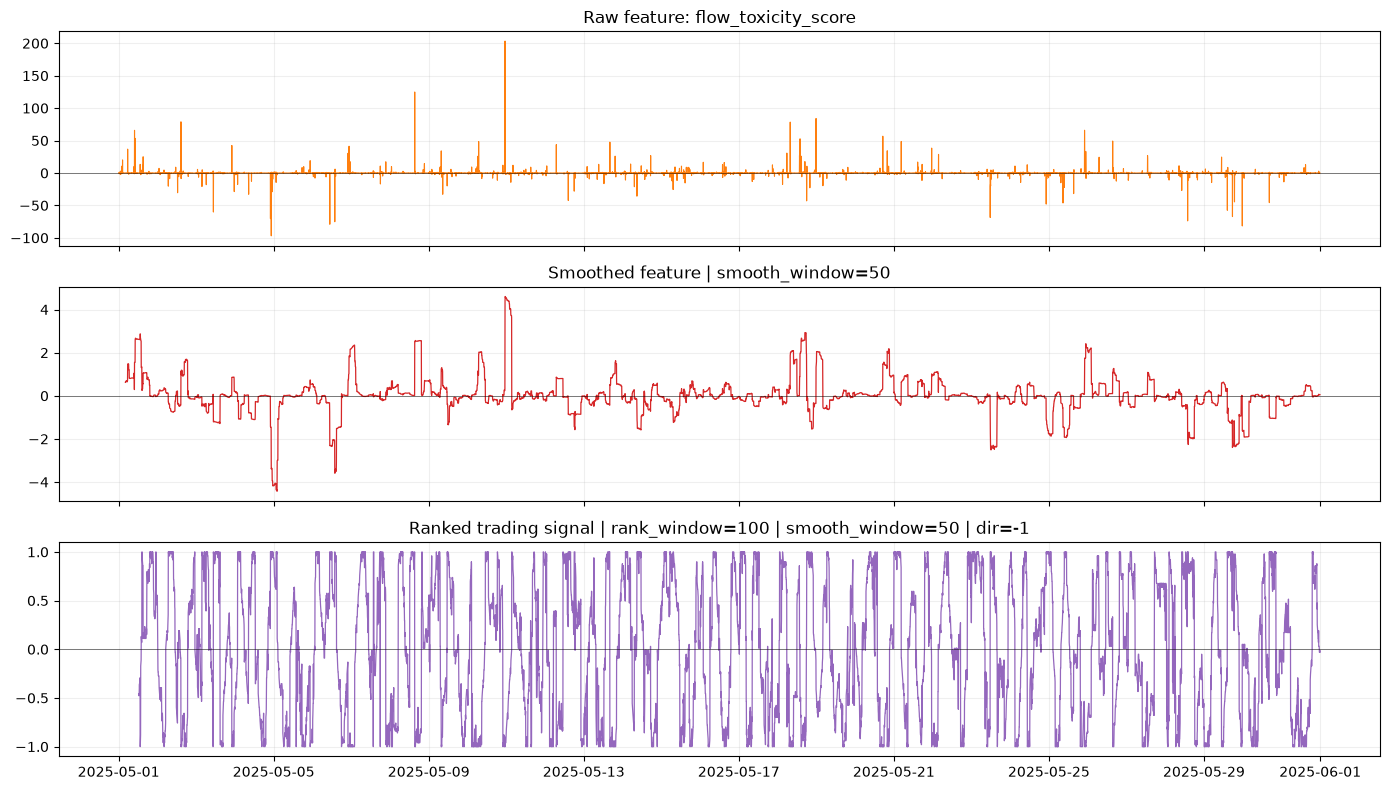

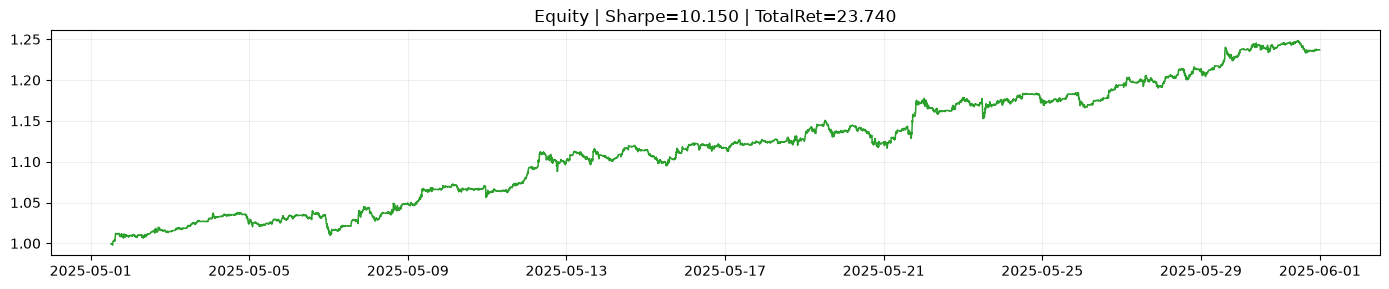

In [4]:
best = results_df.iloc[0].to_dict()
best_feature = str(best["feature"])
best_rank_window = int(best["rank_window"])
best_smooth_window = int(best["smooth_window"])
best_direction = int(best["direction"])

smoothed_feature = smooth_feature(panel, best_feature, best_smooth_window)
signal = make_rank_signal(smoothed_feature, best_rank_window) * best_direction

mask = np.isfinite(signal) & np.isfinite(forward_returns)
bt_frame, bt_summary = run_position_backtest(
    timestamps=panel.loc[mask, "time"],
    position=np.nan_to_num(np.clip(signal[mask], -1.0, 1.0), nan=0.0),
    forward_return=forward_returns[mask],
    cost_bps_one_way=COST_BPS,
)
equity = bt_frame["equity_curve"]

print("Best Strategy found:")
print(best)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(panel["time"], panel[best_feature], linewidth=0.8, color="tab:orange")
axes[0].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[0].set_title(f"Raw feature: {best_feature}")
axes[0].grid(alpha=0.2)

axes[1].plot(panel["time"], smoothed_feature, linewidth=0.9, color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[1].set_title(
    "Smoothed feature"
    f" | smooth_window={best_smooth_window}"
)
axes[1].grid(alpha=0.2)

axes[2].plot(panel["time"], make_rank_signal(smoothed_feature, best_rank_window) * best_direction, linewidth=0.9, color="tab:purple")
axes[2].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[2].set_title(
    "Ranked trading signal"
    f" | rank_window={best_rank_window}"
    f" | smooth_window={best_smooth_window}"
    f" | dir={best_direction}"
)
axes[2].grid(alpha=0.2)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(bt_frame["timestamp"], equity, linewidth=1.1, color="tab:green")
ax.set_title(
    f"Equity | Sharpe={best['sharpe']:.3f} | TotalRet={best['total_return']:.3f}"
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

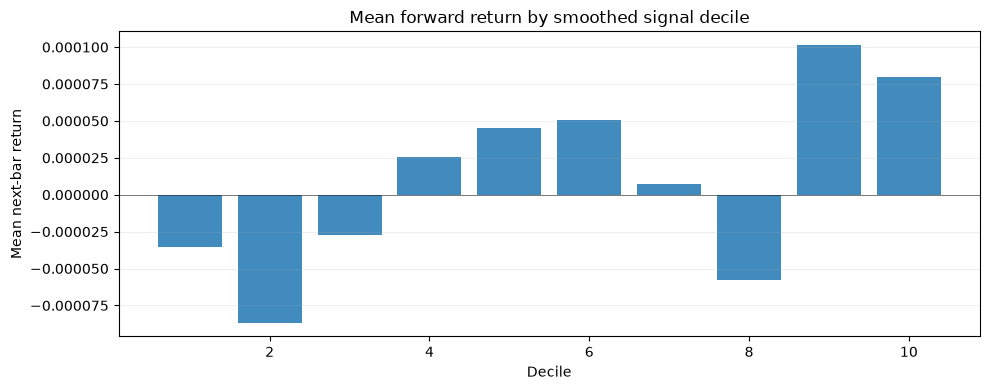

   decile  count  mean_signal  mean_fwd_ret
0       1    878    -0.988795     -0.000036
1       2    878    -0.875267     -0.000087
2       3    878    -0.623018     -0.000027
3       4    878    -0.354778      0.000026
4       5    877    -0.106320      0.000045
5       6    878     0.113044      0.000051
6       7    878     0.390764      0.000007
7       8    878     0.652493     -0.000058
8       9    878     0.886243      0.000101
9      10    877     0.989749      0.000080


In [5]:
mask = np.isfinite(signal) & np.isfinite(forward_returns)
signal_valid = signal[mask]
returns_valid = forward_returns[mask]

if signal_valid.size == 0:
    raise RuntimeError("Best strategy produced no valid observations for decile analysis.")

order = np.argsort(signal_valid)
deciles = np.empty(signal_valid.shape[0], dtype=np.int64)
deciles[order] = (np.arange(signal_valid.shape[0]) * 10 // signal_valid.shape[0]) + 1

deciles_df = pd.DataFrame(
    [
        {
            "decile": decile,
            "count": int((decile_mask := deciles == decile).sum()),
            "mean_signal": float(np.nanmean(signal_valid[decile_mask])),
            "mean_fwd_ret": float(np.nanmean(returns_valid[decile_mask])),
        }
        for decile in range(1, 11)
    ]
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deciles_df["decile"], deciles_df["mean_fwd_ret"], color="tab:blue", alpha=0.85)
ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
ax.set_title("Mean forward return by smoothed signal decile")
ax.set_xlabel("Decile")
ax.set_ylabel("Mean next-bar return")
ax.grid(alpha=0.2, axis="y")
fig.tight_layout()
plt.show()

print(deciles_df)

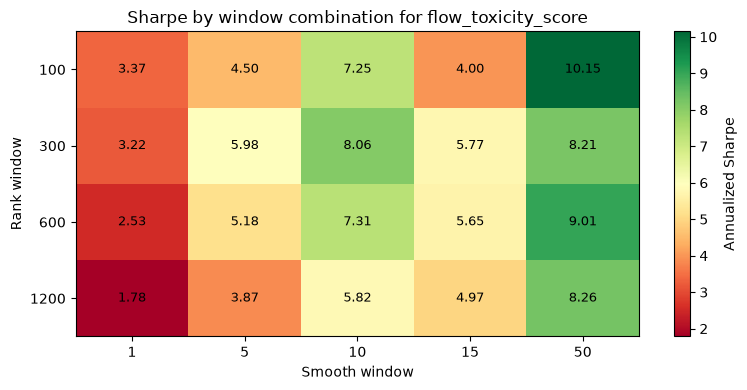

In [6]:
best_feature_results = results_df.loc[
    results_df["feature"] == best_feature,
    ["rank_window", "smooth_window", "sharpe"],
].copy()
heatmap = best_feature_results.pivot(
    index="rank_window", columns="smooth_window", values="sharpe"
).sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="RdYlGn")
ax.set_title(f"Sharpe by window combination for {best_feature}")
ax.set_xlabel("Smooth window")
ax.set_ylabel("Rank window")
ax.set_xticks(np.arange(len(heatmap.columns)), labels=heatmap.columns)
ax.set_yticks(np.arange(len(heatmap.index)), labels=heatmap.index)

for row_idx, row in enumerate(heatmap.to_numpy()):
    for col_idx, value in enumerate(row):
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(image, ax=ax, label="Annualized Sharpe")
fig.tight_layout()
plt.show()

## Next Steps

- Compare whether smoothing improves stability out of sample or only in-sample fit.
- Re-run the search on longer date ranges and alternate venues to check persistence.
- Use the best-ranked smoothed signals as regime filters for broader strategies.